<a href="https://colab.research.google.com/github/LeonardooAlves/WM9B7-AIDL/blob/main/Week%201/3_ANN_Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANNs complete cycle: Forward and Backpropagation

**MSc Applied Artificial Intelligence — AI and Deep Learning Module**  
**WMG, University of Warwick — 2025/26**

---

The following table of contents summarises the sections and concepts covered in this notebook:

## Table of Contents

  * **[1. Introduction to PyTorch and ANN](#Lab:-Introduction-to-PyTorch-and-Artificial-Neural-Networks)**
  * **[2. Basic PyTorch (Tensor Operations)](#Basic-PyTorch-(tensor-operations))**
      * Common tensor initialization (ones, zeros, randn)
      * Converting between NumPy and PyTorch
      * Slicing, indexing, and matrix math
  * **[3. Linear Regression from Scratch](#Linear-Regression-from-Scratch)**
      * Theoretical background (Weight matrix $W$ and Bias vector $B$)
      * Gradient Descent and Loss Functions (MSE)
      * Manual training loop and backpropagation
      * Impact of local minima and learning rates
  * **[4. Logistic Regression for Classification](#From-logistic-regression-to-a-simple-ANN)**
      * Transforming continuous targets to binary variables
      * Implementing the Sigmoid activation function
      * Binary Cross Entropy loss
  * **[5. Building a Simple ANN with MNIST](#The-MNIST-Dataset)**
      * Data preparation and visualization of handwritten digits
      * Refactoring code using `nn.Module`
      * Utilizing `nn.Parameter` and `nn.Linear` layers
      * Optimization algorithms (SGD) and `torch.optim`
  * **[6. Additional Resources](#Additional-resources-/-references)**

# Lab: Introduction to PyTorch and Artificial Neural Networks

### Outline
1. Basic PyTorch operations (tensor fundamentals)
2. Simple linear regression using PyTorch — building a model from scratch
3. Logistic regression using PyTorch — from regression to classification
4. Building a simple ANN using PyTorch — scaling up with `nn.Module`

First, let's set up the environment with a GPU.

In [49]:
# ── Colab environment setup ──────────────────────────────────────────────────
import torch, subprocess, sys, os
from pathlib import Path

# 1. Check GPU availability
if torch.cuda.is_available():
    print(f" GPU detected: {torch.cuda.get_device_name(0)}")
    print(f" CUDA version: {torch.version.cuda}")
else:
    print("No GPU detected — running on CPU (perfectly fine for this lab)")

print(f"PyTorch version: {torch.__version__}")

# 2. Ensure torchvision is available (pre-installed in Colab)
try:
    import torchvision
    print(f"torchvision version: {torchvision.__version__}")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchvision"])
    import torchvision
    print(f"torchvision installed: {torchvision.__version__}")


print("\n── Setup complete ──")

 GPU detected: Tesla T4
 CUDA version: 12.8
PyTorch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128

── Setup complete ──


Take this opportunity to download images from the module's GitHub as needed.

In [50]:
# 3. Download supplementary images from GitHub
GITHUB_REPO = "https://raw.githubusercontent.com/LeonardooAlves/WM9B7-AIDL/main"

images_dir = Path("images")
images_dir.mkdir(exist_ok=True)

# Download learning rate GIF (used in the gradient descent section)
import urllib.request
lr_gif_url = f"{GITHUB_REPO}/Week%201/data/learning_rate.gif"

try:
    if not (images_dir / "learning_rate.gif").exists():
        urllib.request.urlretrieve(lr_gif_url, images_dir / "learning_rate.gif")
        print("Downloaded supplementary images from GitHub")
    else:
        print("Supplementary images already present")
except Exception as e:
    print(f"Could not download images from GitHub: {e}")
    print(" You can upload them manually: click the 📁 icon → upload to images/")
    print(" Alternatively, update GITHUB_REPO above with your repository URL.")

Supplementary images already present


> ** Note on the GitHub URL above**
>
> The `GITHUB_REPO` variable points to a GitHub repository where you can host the supplementary `data/` folder (containing images like `learning_rate.gif`). To set this up:
>
> 1. Create a GitHub repo (public or private) and push your `data/` folder to it.
> 2. Replace `<YOUR_USERNAME>/<YOUR_REPO>` in the cell above with your actual repo path.
>
> **Alternative — manual upload:** If you prefer not to use GitHub, you can upload files directly in Colab by clicking the 📁 folder icon in the left sidebar, then dragging your `images/` folder into the file browser.
>
> For the MNIST dataset itself, we use `torchvision.datasets` below, so no manual download is needed.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F

## Basic PyTorch (tensor operations)

PyTorch tensor operations are essentially the same as those on Numpy arrays. Since PyTorch is specifically geared towards deep learning, there are nice functionalities such as GPU support and automatic gradient calculations.

This section is loosely based on [this tutorial](https://github.com/varal7/ml-tutorial).

**Note:** A refresher for scope of variables in Python will be useful and can be found [here](https://www.w3schools.com/python/python_scope.asp)

### Why tensors?

In deep learning, *everything* is a tensor — a generalisation of scalars, vectors, and matrices to arbitrary dimensions:

| Rank | Name    | Example                        |
|------|---------|--------------------------------|
| 0    | Scalar  | A single loss value: `3.14`    |
| 1    | Vector  | A bias vector: `[0.1, -0.2]`  |
| 2    | Matrix  | A weight matrix: shape `(3,3)` |
| 3+   | Tensor  | A batch of images: `(B,C,H,W)` |

PyTorch tensors live on either CPU or GPU and track gradients automatically when needed — this is what makes backpropagation possible.

Below are some basic tensor operations

In [52]:
# some ones
print(torch.ones(2, 2))

# some zeros
print(torch.zeros(2, 2))

# random values from the unit normal distribution
print(torch.randn(2, 2))

tensor([[1., 1.],
        [1., 1.]])
tensor([[0., 0.],
        [0., 0.]])
tensor([[-1.0733,  0.0943],
        [ 2.0776,  0.7995]])


> **Interpreting the output:** `torch.ones` fills a tensor with 1s, `torch.zeros` with 0s, and `torch.randn` draws each element independently from a standard normal distribution $\mathcal{N}(0,1)$. These are the building blocks you will use to initialise weights and create placeholder tensors.

In [53]:
# Converting between PyTorch tensors and NumPy ndarrays is very simple.

torch_tensor = torch.randn(5, 5)

np_array = torch_tensor.numpy()

print(type(np_array), type(torch_tensor))

back_to_torch = torch.from_numpy(np_array)

<class 'numpy.ndarray'> <class 'torch.Tensor'>


> **Key point:** The NumPy ↔ PyTorch conversion **shares memory** (on CPU). Modifying one will modify the other. If you need an independent copy, use `torch.tensor(np_array)` instead of `torch.from_numpy(np_array)`.

There are far too many tensor operations for us to cover here, so please check out the list over at [the official pytorch tensors documentation](https://pytorch.org/docs/stable/tensors.html)

We will cover a few basic useful ones below.

In [54]:
# create two tensors for use
a = torch.randn(5, 5)
b = torch.randn(5, 5)

print(a)

tensor([[ 0.5770,  0.4747, -0.2684,  0.3254, -0.4428],
        [-1.5735,  0.5126,  0.7850, -1.3877,  0.1587],
        [ 0.2970, -1.9926,  1.0775, -0.8834, -1.3805],
        [-1.3101,  0.0768,  0.6471,  0.5212, -0.8984],
        [ 0.1017,  0.1103,  0.9227,  0.3393, -1.0342]])


In [55]:
# slicing rows and columns etc. work just like in numpy
first_row = a[0, :]
first_col = a[:, 0]
# subarray = a[2:4, 2:4]

print(first_col)

tensor([ 0.5770, -1.5735,  0.2970, -1.3101,  0.1017])


In [56]:
# indexing by i, j
print( torch_tensor)
print(torch_tensor[2, 2])

# the element is returned as another tensor. to get the actual value:
print(torch_tensor[2, 2].item())

tensor([[ 1.6062,  0.2204,  1.1713,  0.3451, -0.5050],
        [ 0.9411, -0.7833,  1.8563, -0.3065,  0.7928],
        [-0.5271,  0.0367, -0.6901,  1.6971,  0.3156],
        [ 0.8322, -0.0026, -0.3830,  1.0184,  0.9533],
        [ 0.2658,  0.7216, -0.4534, -0.6331, -0.0446]])
tensor(-0.6901)
-0.6901060938835144


> **`.item()`** extracts a plain Python number from a single-element tensor. This is essential when you want to log or print a loss value, for example, since loss tensors carry gradient information you typically do not need outside the computation graph.

In [57]:
# addition
c = a + b

# elementwise multiplication
c = a * b

# matrix multiplication
c = a.mm(b)

# multiplication between matrix and vector (try doing this with mm)
c = a.matmul(b[:, 0])

# shorthand version
d = a @ b[:, 0]

> **`@` vs `*`** — This is a common source of confusion:
> - `*` is **element-wise** (Hadamard) multiplication — shapes must match or be broadcastable.
> - `@` (or `.mm()` / `.matmul()`) is **matrix** multiplication — inner dimensions must match.
>
> In deep learning, the forward pass $z = Wx + b$ uses matrix multiplication (`@`), while element-wise operations appear in things like attention masks or gating mechanisms.

# Linear regression from scratch


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Linear_regression.svg/1200px-Linear_regression.svg.png" alt="linear regression" width="550"/>

Now that we know our way around tensors and some basic operations, we can try our hands at coding a linear regression model from scratch. Since we'll be using mean squared error (MSE) as the loss function, this is essentially the same as the least-squares regression that many of you would have encountered in statistics before coming to university.

For least-squares regression, given some data that show a (linear) correlation between the dependent variable and the independent variable, we want to find an equation $y = mx + c$ that captures the correlation between the two variables. Here $m$ is the slope and $b$ is the intercept.

Now suppose that the independent variables are represented by a $\textrm{N}\times \textrm{D} $  matrix $X = [ \mathbf{x}_1, \mathbf{x}_2, ..., \mathbf{x}_N ]^T$, with $\mathbf{x}_1 = [x_1,x_2,...,x_D]$

and, we have $\textrm{L}$ dependent variables, which can be written as a $\textrm{N}\times \textrm{L} $ matrix $Y $.

Then following the same principles as above we can find a ${\textrm{L} \times \textrm{D}}$ weight  matrix $W $ and a $ \textrm{L} \times 1 $ "intercept" (bias) vector $B$ such that

$$ Y = X W^T+  I B^T  $$

where $I$ is $\textrm{N} \times 1 $ matrix of ones

#### How do we find such a matrix $W$ and a vector $B$?

The answer is simple - we start with random numbers and use **gradient descent** to iteratively nudge the numbers in the desired direction.

We first need to define a loss function, though. This is something that calculates a single numerical value that measures the performance of the model. The better our predictions, the lower the loss. This is just a generalisation of the total square of errors in least-square regression.

Once we have a loss, we will be able to compute the direction we need to go in order to decrease the loss. This involves some fairly complicated calculus, but luckily pytorch has ```torch.autograd``` (automatic differentiation) built-in.

<img src="https://upload.wikimedia.org/wikipedia/commons/a/a3/Gradient_descent.gif" alt="gradient descent" width="300">

<!-- ![Gradient descent](https://upload.wikimedia.org/wikipedia/commons/a/a3/Gradient_descent.gif) -->

Let's try it out with an example problem of predicting fruit yields based on the temperature, rainfall, and humidity of different regions. For simplicity we will only predict the amount of apples produced, but in the exercise you will get to extend this model to cover both fruits.

adapted from https://www.kaggle.com/aakashns/pytorch-basics-linear-regression-from-scratch

In [58]:
# data preparation

data = pd.DataFrame(columns = ["region", "temperature", "rainfall", "humidity", "apples", "oranges"])
for i in range(5):
    data.loc[i, "region"] = "ABCDE"[i]

inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]],
                  dtype = "float32"
)
targets = np.array([[56, 70],
                    [81, 101],
                    [119, 133],
                    [22, 37],
                    [103, 119]],
                   dtype = "float32"
)

data[data.columns[1:]] = np.concatenate((inputs, targets), axis = 1)

In [59]:
data

,region,temperature,rainfall,humidity,apples,oranges
0,A,73.0,67.0,43.0,56.0,70.0
1,B,91.0,88.0,64.0,81.0,101.0
2,C,87.0,134.0,58.0,119.0,133.0
3,D,102.0,43.0,37.0,22.0,37.0
4,E,69.0,96.0,70.0,103.0,119.0


> **Interpreting the data:** Each row represents a region (A–E). The first three columns (temperature, rainfall, humidity) are our **input features** ($D=3$). The last two columns (apples, oranges) are the **target outputs** ($L=2$). For now we will predict only apples, giving us a simple $L=1$ regression problem.

In [60]:
# convert inputs and targets to torch tensors

inputs = torch.from_numpy(inputs)
targets = torch.from_numpy(targets[:, 0])

In [61]:
# initialise the weight and bias matrices
# since we will be using the pytorch autograd, we set requires_grad = True

w = torch.randn(1,3, requires_grad = True)
b = torch.randn(1, requires_grad = True)

print(w)
print(b)

tensor([[-1.0112, -0.3056, -0.4384]], requires_grad=True)
tensor([0.2968], requires_grad=True)


> **What `requires_grad=True` does:** It tells PyTorch to record every operation performed on these tensors. This builds a **computational graph** behind the scenes. When we later call `.backward()`, PyTorch walks this graph in reverse to compute $\frac{\partial \text{loss}}{\partial w}$ and $\frac{\partial \text{loss}}{\partial b}$ automatically — this is **automatic differentiation** (autograd).

In [62]:
# define a simple regression model

def model(x):
    return x@w.t()  + b

In [63]:
# try the model by doing some predictions, and compare with the targets
# since the weights are random, it likely won't perform very well

preds = model(inputs)

print(preds.view(1, -1))
print(targets)

tensor([[-112.8435, -146.6678, -154.0481, -132.2049, -129.4959]],
       grad_fn=<ViewBackward0>)
tensor([ 56.,  81., 119.,  22., 103.])


> **Interpreting the output:** The predictions are far from the targets — that is expected since the weights were initialised randomly. The whole point of training is to iteratively adjust `w` and `b` so that predictions move closer to the targets.

In [64]:
# define a loss function.
# since we are comparing numbers, we can use the mean squared error (MSE)

def mse(y1, y2):
    diff = y1 - y2
    return torch.sum(diff * diff) / diff.numel()

> **MSE explained:**
>
> $$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2$$
>
> It squares each prediction error so that positive and negative deviations do not cancel out, then averages across all samples. A lower MSE means better predictions. Because we squared the errors, MSE is always ≥ 0, and equals 0 only when predictions match targets exactly.

In [65]:
# calculate the loss

loss = mse(preds, targets)
print(loss)

# compute the gradients automatically using pytorch
loss.backward()

tensor(46016.7695, grad_fn=<DivBackward0>)


> **What just happened?** Calling `loss.backward()` triggered **backpropagation**. PyTorch traversed the computational graph from the loss back to every tensor with `requires_grad=True` and computed the partial derivatives (gradients). These gradients are now stored in `w.grad` and `b.grad`.

In [66]:
# the gradients are actually stored in the weights themselves
print(w)
print(w.grad)

# similarly for the bias
print(b)
print(b.grad)

tensor([[-1.0112, -0.3056, -0.4384]], requires_grad=True)
tensor([[-35825.2148, -36735.8945, -23142.5957]])
tensor([0.2968], requires_grad=True)
tensor([-422.5040])


> **Reading the gradients:** Each value in `w.grad` tells you: *"If I increase this weight by a tiny amount, the loss will change by approximately this much."* A large positive gradient means the loss is increasing in that direction, so we should **decrease** the weight to reduce the loss — hence we subtract the gradient scaled by the learning rate.

In [67]:
# do one back propagation step

# choose a learning rate (scales the gradient)
lr = 1e-5

# no_grad() tells pytorch not to track the gradients,
# as it is not necessary for the weight update
with torch.no_grad():
    w -= w.grad * lr
    b -= b.grad * lr

    w.grad.zero_()
    b.grad.zero_()

We usually choose a small learning rate to avoid situations where the stride is too wide, making the weights miss the minimum.


<img src="https://github.com/LeonardooAlves/WM9B7-AIDL/blob/main/Week%201/data/learning_rate.gif" width="600"/>

> *If the image above does not render, make sure you ran the setup cell at the top of this notebook, or upload `learning_rate.gif` to the `images/` folder manually.*

> **Why `zero_()` the gradients?** PyTorch **accumulates** gradients by default — each call to `.backward()` **adds** to the existing `.grad` values rather than replacing them. This is useful in some advanced scenarios (e.g., gradient accumulation across micro-batches), but for standard training we must zero them out before each new backward pass to avoid stale gradient information corrupting our updates.

In [68]:
# the weight and bias have now been updated
# and the model should have a lower loss
print(w)
print(b)
preds = model(inputs)
loss = mse(preds, targets)

print(preds.view(1, -1))
print(targets)

print(loss)

tensor([[-0.6530,  0.0618, -0.2070]], requires_grad=True)
tensor([0.3010], requires_grad=True)
tensor([[-52.1225, -66.9237, -60.2271, -71.2997, -53.3060]],
       grad_fn=<ViewBackward0>)
tensor([ 56.,  81., 119.,  22., 103.])
tensor(20002.0391, grad_fn=<DivBackward0>)


> **Check:** The loss should be lower than before. If it is, the gradient descent step worked — we moved the weights in a direction that improved the predictions. One step is rarely enough, though, so next we will train for many epochs.

### Putting it all together and train for multiple epochs

In machine/deep learning language, training for one epoch means that the model has seen all the available training data one time. In almost all cases multiple epochs is needed for optimal performance - let's try training for 500 epochs and plot the losses to see how our model turns out.

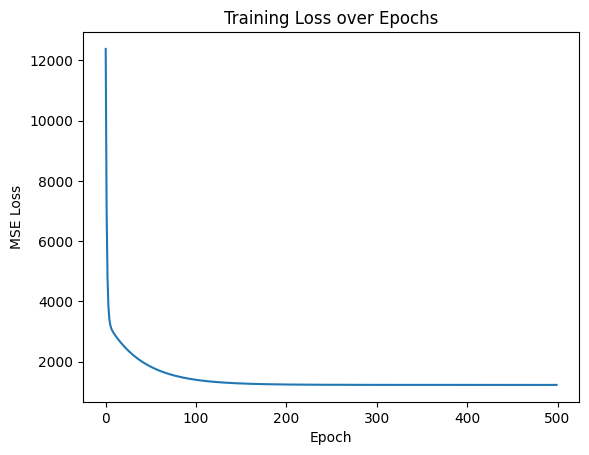

In [69]:
# initiate the parameters
w = torch.randn(1, 3, requires_grad = True)
b = torch.randn(1, requires_grad = True)

# choose a number of epochs
num_epochs = 500
lr = 1e-5

# store the losses for plotting
losses_storage = np.zeros(num_epochs)

for i in range(num_epochs):
    preds = model(inputs)
    loss = mse(preds, targets)
    loss.backward()

    with torch.no_grad():
        w -= w.grad * lr
        b -= b.grad * lr
        w.grad.zero_()
        b.grad.zero_()

    losses_storage[i] = loss.item()

plt.plot(losses_storage)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss over Epochs")
plt.show()

> **Interpreting the loss curve:** You should see a rapid decrease in loss during the first ~100 epochs, followed by a plateau. The rapid phase is the model finding the general direction of the optimum; the plateau means the model has **converged** (or at least reached a region where further improvement is very slow).

In [70]:
# compare our outputs to actual values
print(preds.view(1, 5).round())
print(targets)

tensor([[64., 84., 79., 78., 73.]], grad_fn=<RoundBackward0>)
tensor([ 56.,  81., 119.,  22., 103.])


We can see that the model/network has been saturated (it cannot improve any more) as the training loss has leveled off, but the final predictions aren't great. This could be due to several reasons, for example

* this is a very simple model/network with only a few parameters, so it is not very powerful.
* the task is quite difficult as we are trying to predict exact numbers
* the weights may be stuck at a local minimum


<img src="https://bdtechtalks.com/wp-content/uploads/2020/04/gradient-descent-local-minima.png" width="500"/>

To illustrate the effect of local minima, I have some code below that will train 100 models, each for 100 epochs (hopefully enough for saturation). The histogram shows the lowest loss achieved lies around 1300. Though this seems to be the most common final loss, we did have a sizeable number of models bottoming out at 1400+ which suggest that they failed to reach the global minima.

There are more complex versions of the gradient descent algorithm that attempt to deal with problems like this. PyTorch has a great number of optimizers built-in, and we will briefly touch on them in the next session.

In [71]:
# feel free to lower the numbers if this takes a long time to run
# we just need a large enough sample size - say 20

num_repeats = 100
final_losses = []

# choose a number of epochs
num_epochs = 100
lr = 1e-5

for _ in range(100):
    # initiate the parameters
    w = torch.randn(1, 3, requires_grad = True)
    b = torch.randn(1, requires_grad = True)

    for i in range(num_epochs):
        preds = model(inputs)
        loss = mse(preds, targets)
        loss.backward()

        with torch.no_grad():
            w -= w.grad * lr
            b -= b.grad * lr
            w.grad.zero_()
            b.grad.zero_()

    final_losses.append(loss.item())

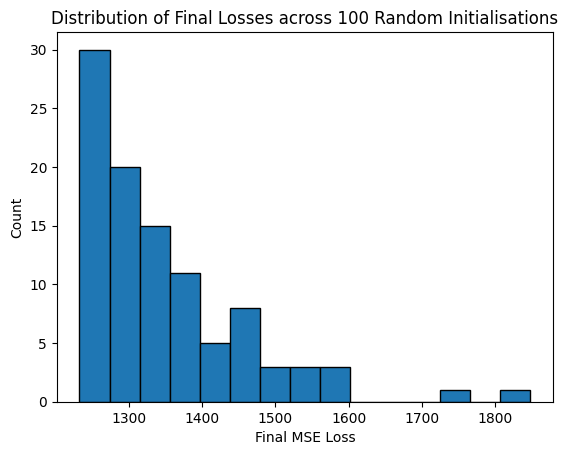

In [72]:
plt.hist(final_losses, bins=15, edgecolor='black')
plt.xlabel("Final MSE Loss")
plt.ylabel("Count")
plt.title("Distribution of Final Losses across 100 Random Initialisations")
plt.show()

> **Interpreting the histogram:** The spread of final losses illustrates a key challenge in optimisation — **sensitivity to initialisation**. Each model started from different random weights, and some converged to worse solutions (higher loss) than others. This is direct evidence of the local minima problem. More advanced optimisers (Adam, RMSprop) and techniques like learning rate scheduling help mitigate this.

# Convert to classification

Classification follows the same principles - we still have some input data, some weights and biases that we train using gradient descent which give us some outputs. Except this time by definition the output/target is categorical instead of numerical.

Let us modify the dataset to predict whether apple production will be >100 or <=100. This will be a simple binary classification.

In [73]:
# transform the target values into a binary variable
print(targets)

labels = targets > 100
labels = labels.long()
print(labels)

tensor([ 56.,  81., 119.,  22., 103.])
tensor([0, 0, 1, 0, 1])


> **What just happened?** We converted the continuous target (number of apples) into a binary label: `1` if production exceeds 100, `0` otherwise. This transforms a **regression** problem into a **classification** problem. Notice that regions A, B, and D have production ≤ 100 (label `0`), while regions C and E exceed 100 (label `1`).

## Logistic regression model
We modify our linear regression model to perform classification using logistic regression. We do this by adding a non-linearity in the form of a sigmoid function. The purpose of this is to squish the outputs of the model towards either 0 (negative) or 1 (positive). These are also essential for building networks with more layers, since stacking linear transformations on top of each other just results in a single linear transformation.

The sigmoid function is defined as:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

It maps any real number to the range $(0, 1)$, which we can interpret as a **probability** of belonging to the positive class.

![sigmoid](https://qph.fs.quoracdn.net/main-qimg-6b67bea3311c3429bfb34b6b1737fe0c)

In [74]:
# we add a non-linearity in the form of a sigmoid

w = torch.randn(1, 3, requires_grad = True)
b = torch.randn(1, requires_grad = True)

def classification_model(x):
    # calculate as before
    h =  w @x.t()+ b

    # add on a sigmoid activation function
    y = 1 / (1 + torch.exp(-h))

    return y

# use binary cross entropy as our loss function
# we cheat and use the built in binary cross entropy implementation
# this will be covered more in the next session
import torch.nn as nn
loss_fn = nn.BCELoss()

> **Why Binary Cross-Entropy (BCE)?** For classification, MSE is a poor choice because its gradients become very small when the sigmoid output is near 0 or 1 (the "vanishing gradient" problem). BCE is specifically designed for binary classification:
>
> $$\text{BCE} = -\frac{1}{N}\sum_{i=1}^{N}\left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$
>
> It penalises confident wrong predictions very heavily (logarithmic penalty), which gives much stronger gradients and faster learning.

In [75]:
# train the model for some epochs
# note that the inputs have been scaled down
# so that the outputs of the sigmoid does not blow up

lr = 0.5
num_epochs = 2000
losses_storage = np.zeros(num_epochs)

for i in range(num_epochs):
    predictions = classification_model(inputs/100)
    loss = loss_fn(predictions.squeeze(), labels.float())
    loss.backward()

    with torch.no_grad():
        w -= w.grad * lr
        b -= b.grad * lr
        w.grad.zero_()
        b.grad.zero_()

    losses_storage[i] = loss.item()

> **Why divide inputs by 100?** The raw inputs (temperatures 69–102, rainfall 43–134, etc.) are large numbers. When multiplied by weights and passed through the sigmoid, they can produce values extremely close to 0 or 1, making gradients vanishingly small. Dividing by 100 brings inputs into a manageable range. In practice, we use proper **feature scaling** (standardisation or normalisation) rather than this ad-hoc division.

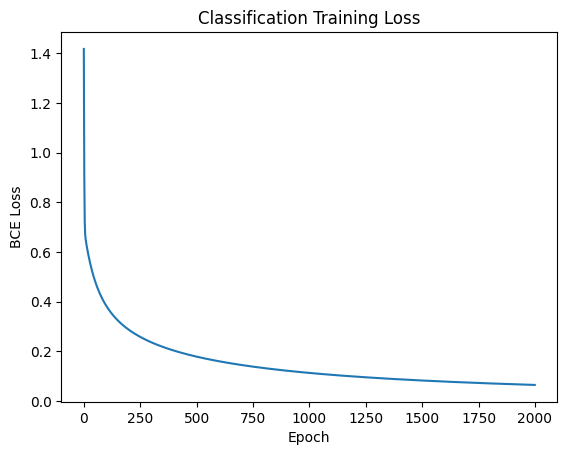

Predictions (rounded): tensor([0., 0., 1., 0., 1.], grad_fn=<SqueezeBackward0>)
True labels:           tensor([0, 0, 1, 0, 1])


In [76]:
plt.plot(losses_storage)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Classification Training Loss")
plt.show()

print("Predictions (rounded):", predictions.round().squeeze())
print("True labels:          ", labels)

> **Interpreting the results:** If all rounded predictions match the true labels, the classifier has achieved 100% accuracy on this tiny training set. The loss curve should show a smooth decrease toward zero. With only 5 samples this is not surprising — the real challenge comes with larger, noisier datasets like MNIST below.

# From logistic regression to a simple ANN

We now scale up from our toy 5-sample problem to a real-world dataset with tens of thousands of examples. The architecture principles remain the same — we just need more parameters and more structured code to handle the complexity.

## The MNIST Dataset

The dataset we use is the **MNIST** hand-written digits dataset. This consists of 28×28 pixel grayscale images of hand-drawn digits between 0 and 9. It is often referred to as the "hello world" of machine learning.

Each image is stored as a flattened vector of 784 values (28 × 28 = 784), where each value is a pixel intensity between 0.0 (black) and 1.0 (white). The task is **multi-class classification**: given an image, predict which digit (0–9) it represents.

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch
import torchvision
from torch import nn

### Loading the data

We use `torchvision.datasets.MNIST` which automatically downloads the dataset. This is the recommended approach as it avoids manual file management and works seamlessly.

We then split the standard 60,000 training images into 40,000 for training and 10,000 for validation (keeping a similar split to the original notebook), and retain the 10,000 test images separately.

In [78]:
# ── Load MNIST using torchvision ──────────────────────────────────────────────
# This downloads the dataset automatically on first run (~12 MB)

from torchvision import datasets, transforms

# Download and load the full training set (60,000 images)
mnist_train_full = datasets.MNIST(
    root='./data',           # download location
    train=True,              # training split
    download=True,           # download if not present
    transform=None           # we'll handle conversion manually below
)

# Download and load the test set (10,000 images)
mnist_test = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=None
)

# Extract data as numpy arrays and normalise pixel values to [0, 1]
x_full = mnist_train_full.data.numpy().astype('float32') / 255.0
y_full = mnist_train_full.targets.numpy().astype('int64')

# Flatten images from 28x28 to 784-dimensional vectors
x_full = x_full.reshape(-1, 784)

# Split into training (first 40,000) and validation (remaining 10,000)
# to match the original notebook's 80/20 split
x_train = x_full[:40000]
y_train = y_full[:40000]
x_valid = x_full[40000:50000]
y_valid = y_full[40000:50000]

print(f"Training set:   {x_train.shape[0]:,} samples, {x_train.shape[1]} features each")
print(f"Validation set: {x_valid.shape[0]:,} samples")
print(f"Pixel range:    [{x_train.min():.1f}, {x_train.max():.1f}]")
print(f"Labels:         {y_train.min()} to {y_train.max()}")

Training set:   40,000 samples, 784 features each
Validation set: 10,000 samples
Pixel range:    [0.0, 1.0]
Labels:         0 to 9


> **Why 40k/10k split?** In practice, we want a large enough training set for the model to learn meaningful patterns, and a separate validation set to monitor generalisation. The 80/20 split is a common starting point. Note that "validation" and "test" are used interchangeably here, but strictly speaking they refer to different things. [This website](https://machinelearningmastery.com/difference-test-validation-datasets/) is a good starting point if you're unsure about the difference.

Let's plot some images to make sure everything is as expected

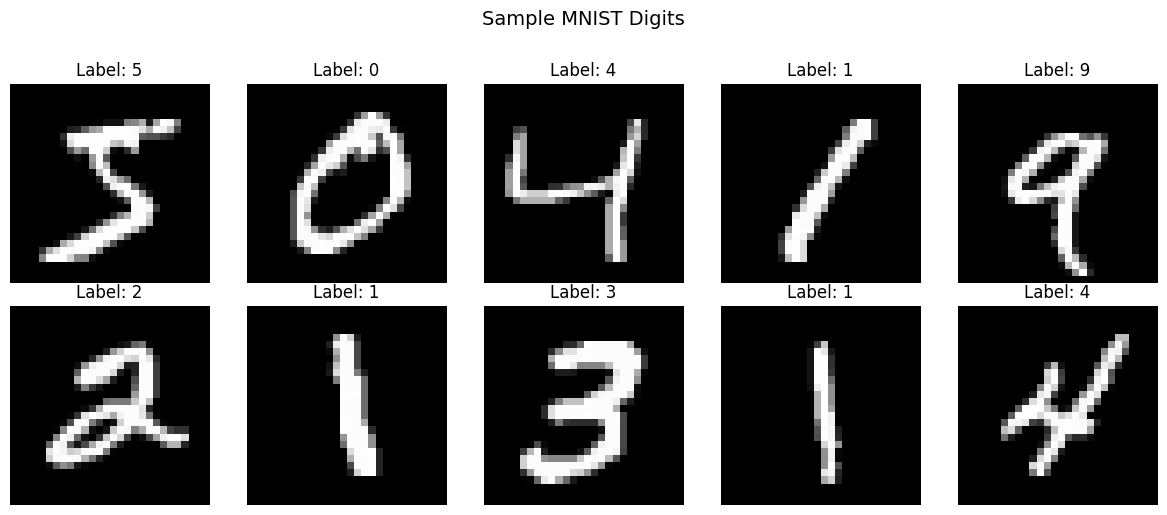

In [79]:
# plot a grid of example digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flat):
    ax.imshow(x_train[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y_train[idx]}", fontsize=12)
    ax.axis("off")
plt.suptitle("Sample MNIST Digits", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Alternatively, you can download the MNIST dataset as a pickle file, as shown below.

**If you already downloaded the MNIST data using PyTorch above, you do not need to run the immediate cell below. Only run it if you prefer to import instead of using PyTorch**

In [80]:
import os
import gzip
import pickle
import requests
from pathlib import Path

# Create directory structure
DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"
PATH.mkdir(parents=True, exist_ok=True)

# URL for the standard MNIST pickle file
URL = "https://github.com/mnielsen/neural-networks-and-deep-learning/raw/master/data/mnist.pkl.gz"
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
    print("Downloading MNIST dataset...")
    content = requests.get(URL).content
    (PATH / FILENAME).open("wb").write(content)

# Load the data
with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

print(f"Dataset loaded. Training shape: {x_train.shape}")

Dataset loaded. Training shape: (50000, 784)


true label:  5


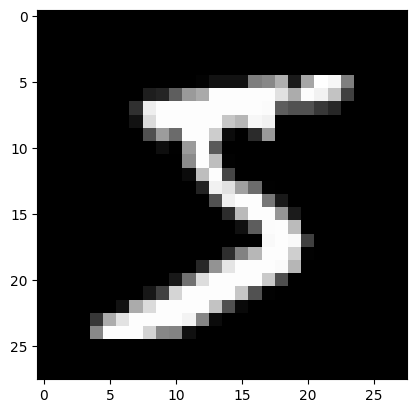

In [81]:
# plot one example
plt.imshow(x_train[0].reshape((28, 28)), cmap = "gray");
print("true label: ", y_train[0].item())

> **What you should see:** handwritten digits displayed as grayscale images, each with its true label. Notice the variation in handwriting styles — some digits are slanted, thicker, or positioned differently within the 28×28 frame. This variation is what makes classification non-trivial and why we need models with enough capacity to generalise.

In [82]:
# before we can work with them, they need to be converted
# into torch.tensors

x_train, y_train, x_valid, y_valid = map(
    torch.tensor, (x_train, y_train, x_valid, y_valid))

# Obtain the number of samples and features
n, c = x_train.shape

print(x_train.shape)
print(y_train.min(), y_train.max())

torch.Size([50000, 784])
tensor(0) tensor(9)


> **Tensor shapes:** `x_train` has shape `(40000, 784)` — 40,000 images, each flattened into a 784-dimensional vector. `y_train` contains integer labels from 0 to 9. These are the inputs and targets for our neural network.

## Using ```nn.Module```

Instead of defining all the mathematical operations ourself, like we did in tutorial 1 as

```
def classification_model(x):
    # calculate as before
    h =  w @x.t()+ b

    # add on a sigmoid activation function
    y = 1 / (1 + torch.exp(-h))

    return y
```

Let's define a `model` based on the ```nn.Module``` class. This is the base class for all neural network modules ([official documentation](https://pytorch.org/docs/stable/generated/torch.nn.Module.html)), so anything we define on top of this will automatically inherit all the nice built-in functions.

Two very useful functions are
1. ```model.eval()``` i.e. ```nn.Module.eval() ```
2. ```model.forward()```

We can call ```model.eval()``` to put the model into evaluation mode and automatically freeze all of the weights.

We will first build our model and incrementally add inbuilt `torch.nn` functions and modules

First, we use ```nn.Parameter``` to define the weights and biases. This tells the model that these are its parameters (`requires_grad` is set to `True` by default) - this becomes useful when doing back propagation, as we can iterate through all the parameters instead of needing to explicitly update each one.

In [83]:
class Mnist_Logistic(nn.Module):
    # __init__ contains the setup/architecture of the model
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(784, 10) / np.sqrt(784))# requires_grad is set to true by default
        self.bias = nn.Parameter(torch.zeros(10))

    # forward tells the model what to compute when we feed inputs in
    def forward(self, x):
        return x @ self.weights + self.bias

> **Weight initialisation:** Notice the division by $\sqrt{784}$. This is a form of **Xavier/Glorot initialisation** — it scales the random weights so that the variance of the outputs is approximately equal to the variance of the inputs. Without this, the outputs of a 784-input layer would have very large variance, causing training instability.

> **The `forward` method:** When you call `model(x)`, PyTorch internally calls `model.forward(x)`. This is the method where you define the computation your model performs. The `__init__` method defines the *architecture* (what parameters exist), while `forward` defines the *computation* (how data flows through those parameters).

Since the model is now defined as a class, we need to instantiate the model.

Let's choose the cross entropy from ```torch.nn.functional``` (F). This is a generalised version of binary cross entropy so that it can deal with multiple output variables.

>*``torch.nn.functional`` contains all the operations or building blocks we might need when we construct our own networks - things like convolution or pooling. All details in Pytorch documentation [here](https://pytorch.org/docs/stable/nn.functional.html#)*

In [84]:
model = Mnist_Logistic()
loss_fn = F.cross_entropy

> **Cross-Entropy Loss** generalises BCE to multiple classes. For a sample with true label $k$ and predicted probabilities $\hat{p}_1, ..., \hat{p}_{10}$:
>
> $$\text{CE} = -\log(\hat{p}_k)$$
>
> It only penalises the probability assigned to the correct class. `F.cross_entropy` expects **raw logits** (not softmax probabilities) — it applies softmax internally for numerical stability.

In [85]:
# do one gradient calculation as before
loss = loss_fn(model(x_train), y_train)
loss.backward()

This is how we updated the weights before, but for more complex models this gets cumbersome as we would need to update each weight individually.

``` with torch.no_grad():
    weights -= weights.grad * lr
    bias -= bias.grad * lr
    weights.grad.zero_()
    bias.grad.zero_() ```
    
With the help of `nn.Parameter`, we can now iterate through all the parameters (weights and biases etc.) to update them without the need to explicitly write out each one individually.

In [86]:
lr = 0.5

with torch.no_grad():
    for p in model.parameters(): p -= p.grad * lr
    model.zero_grad()

> **`model.parameters()`** returns an iterator over all `nn.Parameter` objects in the model. This is far more maintainable than manually listing every weight and bias — especially when models have dozens or hundreds of layers.

### Training with mini-batches

Remember that the training set contains 40,000 samples and the validation/test set contains 10,000 for an 80/20 split. Since these are fairly large numbers, we might run into memory problems if we try to load all of them at once.

We solve this by training and testing in small batches of predetermined ```batch_size```. In general, the larger the batch size, the more representative each batch will be for the entire population, and therefore the more similar batches will be to each other, allowing a smoother training process.

This is one of the many hyperparameters we need to give the model. Other essential ones include the learning rate and the number of epochs to train for, which we covered in the previous session.

Choosing what hyperparameters to use is more of an art than an exact science, though you will naturally get a grasp on what to use as you gain more experience.

A training loop now looks like this - we have wrapped it inside the ```fit()``` function to be used later.

In [87]:
# define some hyperparameters to tell the model
lr = 0.5
num_epochs = 10
train_size = n
batch_size = 10000
losses_storage = []

model = Mnist_Logistic()
loss_fn = F.cross_entropy

def fit():

    for epoch in range(num_epochs):
        for i in range((train_size - 1) // batch_size + 1):
            start_i = i * batch_size
            end_i = start_i + batch_size
            x_batch = x_train[start_i:end_i]
            y_batch = y_train[start_i:end_i]


            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)

            loss.backward()
            with torch.no_grad():
                for p in model.parameters():
                    p -= p.grad * lr
                model.zero_grad()
            losses_storage.append(loss.item())

fit()

> **How the batching loop works:** With 40,000 samples and a batch size of 10,000, each epoch processes 4 batches. Over 10 epochs, that is 40 weight update steps total. Each step computes the loss on a single batch, backpropagates, and updates the weights. The `losses_storage` list records one loss value per batch — so you should see 40 entries.

**Task:** The process of loading data and splitting it into batches can be further simplified using [Dataset](https://pytorch.org/tutorials/beginner/nn_tutorial.html#refactor-using-dataset) and
[DataLoader](https://pytorch.org/tutorials/beginner/nn_tutorial.html#refactor-using-dataloader), explore them.

## Using nn.Linear

```nn.Linear``` gives us a fully connected layer (each input neuron is connected to each output neuron, where each neuron is just a number) which is the basic building block of artificial neural networks (ANNs). Below we have defined an ANN with a single layer going straight from inputs to outputs to use for MNIST classification.

![MNIST ANN](https://ml4a.github.io/images/figures/mnist_1layer.png)

In [88]:
class Mnist_Logistic(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features = 784,
            out_features = 10
        )

    def forward(self, x):
        return self.linear(x) # return the un-normalised preactivations as required by cross entropy loss function.

> **`nn.Linear` vs manual weights:** `nn.Linear(784, 10)` internally creates a weight matrix of shape `(10, 784)` and a bias vector of shape `(10)`, both as `nn.Parameter` objects with proper initialisation. This is exactly equivalent to our manual approach above, but cleaner and less error-prone.

> Aside on terminology:

Output of **nn.Linear**: this is the raw affine transform

$z = Wx + b$

It is just a weighted sum plus bias.

**Preactivation**: a general name for the value before applying a nonlinearity (e.g., ReLU, sigmoid, softmax).
So for a linear layer followed by activation, the preactivation is exactly the nn.Linear output.

**Logit**: usually refers to the final layer preactivation used for classification.

**Multi-class**: logits are the class scores before softmax.
**Binary**: a single logit is the score before sigmoid.

So, nn.Linear output = preactivation, and when that preactivation is at the classifier head, it is called logits.

In [89]:
model = Mnist_Logistic()
print(loss_fn(model(x_train), y_train))

tensor(2.3025, grad_fn=<NllLossBackward0>)


> **Initial loss sanity check:** For a 10-class classification with random weights, the expected initial loss is approximately $-\log(1/10) \approx 2.30$. If you see a value near 2.3, the model and loss function are wired up correctly. A value significantly different from 2.3 would suggest a bug.

In [90]:
lr = 0.5
num_epochs = 10
train_size = n
batch_size = 10000
losses_storage = []

fit()

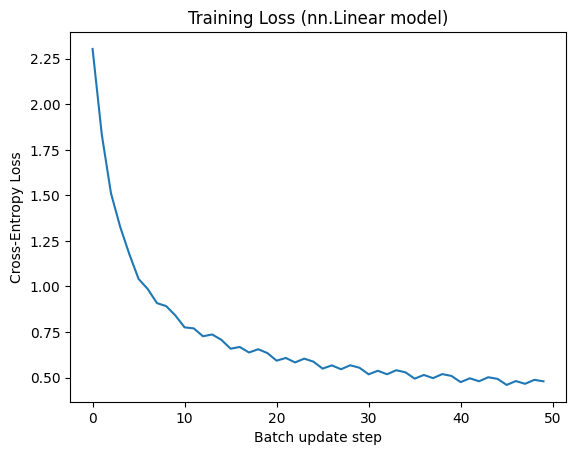

In [91]:
plt.plot(losses_storage)
plt.xlabel("Batch update step")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss (nn.Linear model)")
plt.show()

As the loss levels off, it starts to fluctuate. This indicates that the model is overfitting - it is learning the noise/small deviations that are naturally present within the data. This is of course particular to each individual sample and each batch of samples. The fluctuation is caused by different batches having different quirks and pulling the model weights in different directions.

In general we want to stop training when the training loss shows signs of overfitting (fluctuation) and the validation loss stops improving, signalling that the model has been saturated.

> **Key insight:** The fluctuations are a characteristic of **mini-batch** gradient descent. If we used the full dataset for every update (batch gradient descent), the curve would be smooth but each step would be very expensive. Mini-batches trade off noise in the gradient for computational efficiency — and the noise can actually help escape shallow local minima.

### Optimizers

Optimizers exist so we do not have to manually update the parameter/weights and pytorch has the popular ones already implemented. This is especially useful when we want to use something more complex than standard gradient descent, e.g. stochastic gradient descent (SGD), RMSprop, Adam, etc... [Refer here](https://ruder.io/optimizing-gradient-descent/index.html) for an overview by Sebastian Ruder. List of available algorithms is [here](https://pytorch.org/docs/stable/optim.html#algorithms).

Common optimizers and when to use them:

| Optimizer | Key Idea | When to Use |
|-----------|----------|-------------|
| **SGD**   | Vanilla gradient descent (+ optional momentum) | Good baseline, often preferred for CNNs |
| **Adam**  | Adaptive learning rates per parameter | General-purpose default, good for most tasks |
| **RMSprop** | Divides by running average of gradient magnitudes | Works well for RNNs and non-stationary objectives |

In [92]:
from torch import optim

we can use ``optim`` to replace the previously manually coded gradient update

``with torch.no_grad():
    for p in model.parameters(): p -= p.grad * lr
    model.zero_grad()
``

In [93]:
# we'll be using SGD for this example

model = Mnist_Logistic()
opt = optim.SGD(model.parameters(), lr=lr)

print(loss_fn(model(x_train), y_train))

tensor(2.3394, grad_fn=<NllLossBackward0>)


In [94]:
# run model

lr = 0.5
num_epochs = 10
train_size = n
batch_size = 10000
losses_storage = []


for epoch in range(num_epochs):
    for i in range((train_size - 1) // batch_size + 1):
        start_i = i * batch_size
        end_i = start_i + batch_size
        x_batch = x_train[start_i:end_i]
        y_batch = y_train[start_i:end_i]
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)

        loss.backward()
        # this is the only difference
        opt.step()
        opt.zero_grad()

        losses_storage.append(loss.item())

> **`opt.step()` + `opt.zero_grad()`** — These two lines replace the entire manual weight update block. `opt.step()` applies the optimiser's update rule (for SGD: $w \leftarrow w - lr \cdot \nabla w$), and `opt.zero_grad()` resets all gradients to zero. For more advanced optimisers like Adam, `step()` also maintains internal running averages of gradients and squared gradients — something that would be tedious to implement manually.

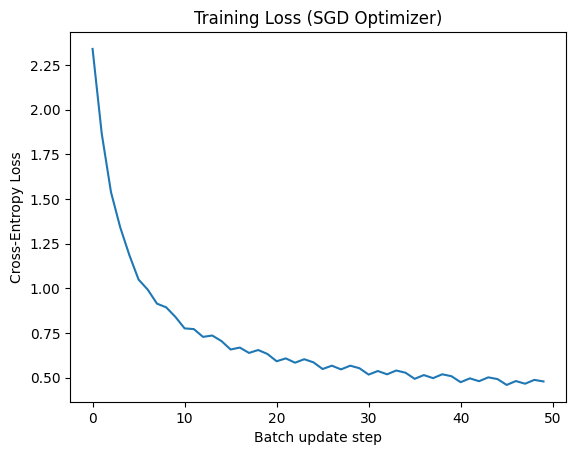

In [95]:
plt.plot(losses_storage)
plt.xlabel("Batch update step")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss (SGD Optimizer)")
plt.show()

### Evaluating on the validation set

Training loss tells us how well the model fits the training data, but what we really care about is **generalisation** — how well does it perform on data it has never seen? Let's compute the accuracy on the validation set.

In [96]:
# evaluate on the validation set
model.eval()  # switch to evaluation mode

with torch.no_grad():
    val_preds = model(x_valid)
    val_loss = loss_fn(val_preds, y_valid)

    # get predicted class (highest logit)
    predicted_labels = val_preds.argmax(dim=1)
    accuracy = (predicted_labels == y_valid).float().mean()

print(f"Validation Loss:     {val_loss.item():.4f}")
print(f"Validation Accuracy: {accuracy.item()*100:.1f}%")

Validation Loss:     0.4241
Validation Accuracy: 89.3%


> **Interpreting validation accuracy:** With a single linear layer (no hidden layers, no activation functions), this model is essentially performing multi-class logistic regression. You should see an accuracy around 85–90% — impressive for such a simple model, but far from state-of-the-art. Adding hidden layers with non-linear activations (i.e., building a proper ANN) would push this significantly higher.

# Additional resources / references

- Basic PyTorch / tensors: https://github.com/varal7/ml-tutorial
- 3Blue1Brown neural network series on YouTube: https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi
- Kaggle regression tutorial: https://www.kaggle.com/aakashns/pytorch-basics-linear-regression-from-scratch
- PyTorch official tutorials: https://pytorch.org/tutorials/
- Gradient descent optimizers overview (Sebastian Ruder): https://ruder.io/optimizing-gradient-descent/